# Zhang et al. (2022) Comparator — MobileNetV2 + TSM — 1 Seed per Colab Session

Notebook ini adalah **external lightweight comparator** untuk EffTemp-Net.

**Model:** `MobileNetV2 + TSM`  
**Training/testing data:** split dan dataset milik eksperimen EffTemp-Net  
**RWF:** tetap held-out dan tidak masuk pooled 411.

## Protocol
**Method-specific dari Zhang et al. (2022):**
- MobileNetV2 pretrained;
- RGB;
- 8 temporal segments;
- batch size 8;
- Adam;
- initial LR `3.75e-4`;
- Adam first-moment coefficient `0.9`;
- 100 epochs;
- average temporal consensus;
- TSM `shift_div=8` untuk varian TSM.

**Shared controlled protocol dari EffTemp-Net:**
- fixed train/validation identities yang sama;
- `FIXED_SPLIT_SEED=42`;
- cache 16-frame 64×64 yang sama;
- augmentation, normalization, evaluation metrics, pooled set, RWF held-out, bootstrap, dan latency pipeline yang sama;
- no label smoothing;
- best checkpoint dipilih dengan validation Macro-F1.

**Important:** paper Zhang et al. menyatakan Adam. Official repository mereka saat ini memiliki active SGD code. Notebook ini memprioritaskan konfigurasi yang tertulis di paper ketika paper dan repository tidak konsisten.

Learning-rate decay dibuat deterministik `0.85×` setiap 2 epoch mengikuti strategi yang dijelaskan di paper, **tanpa tuning berdasarkan test set**.

In [1]:
# Jalankan sekali pada awal sesi Colab
!pip -q install ptflops

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import json
import math
import time
import random
import shutil
import platform
import warnings
from contextlib import nullcontext
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from torchvision.models.mobilenetv2 import InvertedResidual
import torchvision.transforms.functional as TF
from torchvision.transforms import RandomResizedCrop, InterpolationMode

from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_fscore_support,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
)

warnings.filterwarnings("ignore", category=UserWarning)

print("Python      :", platform.python_version())
print("PyTorch     :", torch.__version__)
print("torchvision :", torchvision.__version__)
print("CUDA        :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU         :", torch.cuda.get_device_name(0))

Python      : 3.12.13
PyTorch     : 2.11.0+cu128
torchvision : 0.26.0+cu128
CUDA        : True
GPU         : NVIDIA A100-SXM4-40GB


## 1. Konfigurasi

Untuk menjalankan seed lain secara paralel, **cukup ubah `RUN_SEED`** menjadi `0`, `42`, atau `123`.

`FIXED_SPLIT_SEED=42` **jangan diubah**.

In [4]:
# ============================================================
# HANYA UBAH BARIS INI untuk menjalankan seed lain.
# ============================================================
RUN_SEED = 123
SEEDS = [RUN_SEED]

MODEL_VARIANT = "mobilenet_tsm"
USE_TSM = True

# =========================
# PATH — sama dengan EffTemp-Net
# =========================
DATA_ROOT = Path("/content/drive/MyDrive/IVS/ViolenceDataset/EffTempNet_Data")
CACHE_DIR = Path("/content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/new_saved_dataset")

OUTPUT_DIR = Path(
    f"/content/drive/MyDrive/IVS/ViolenceDetection/Models/Comparators/"
    f"{MODEL_VARIANT}_Seed{RUN_SEED}_v1"
)

TRAINVAL_DIR = DATA_ROOT / "TrainVal" / "Gabung"
RWF_RAW_DIR = Path("/content/drive/MyDrive/IVS/ViolenceDataset/Benchmark/RWF")

TEST_SPECS = {
    "HF":   {"raw_dir": DATA_ROOT / "Testing" / "HockeyFight",  "cache_name": "HockeyFight"},
    "MF":   {"raw_dir": DATA_ROOT / "Testing" / "MovieFight",   "cache_name": "MovieFight"},
    "VCF":  {"raw_dir": DATA_ROOT / "Testing" / "ViolentFlow", "cache_name": "ViolentFlow"},
    "AVDV": {"raw_dir": DATA_ROOT / "Testing" / "Automatic",   "cache_name": "Automatic"},
    "SCFD": {"raw_dir": DATA_ROOT / "Testing" / "SurveilFight","cache_name": "Surveilence"},
    "RLVS": {"raw_dir": DATA_ROOT / "Testing" / "Realife",     "cache_name": "Realife"},
    "RWF":  {"raw_dir": RWF_RAW_DIR,                           "cache_name": "RWF"},
}

POOLED_DATASETS = ["HF", "MF", "VCF", "AVDV", "SCFD", "RLVS"]

# =========================
# DATA
# =========================
CLASS_NAMES = ["NonViolence", "Violence"]
NUM_CLASSES = 2

CACHE_SEQUENCE_LENGTH = 16
RAW_HEIGHT = 64
RAW_WIDTH = 64

# Zhang/TSM setting
NUM_SEGMENTS = 8
BACKBONE_INPUT_SIZE = 224
SEGMENT_WIDTH = CACHE_SEQUENCE_LENGTH // NUM_SEGMENTS

VAL_RATIO = 0.11
FIXED_SPLIT_SEED = 42

PREFER_LEGACY_CACHE = True
LEGACY_CACHE_COLOR_ORDER = "BGR"
AUTO_SCALE_LEGACY_CACHE = True

# =========================
# ZHANG ET AL. 2022 — METHOD-SPECIFIC
# =========================
MAX_EPOCHS = 100
BATCH_SIZE = 8

LEARNING_RATE = 3.75e-4
ADAM_BETAS = (0.9, 0.999)
WEIGHT_DECAY = 0.0
LABEL_SMOOTHING = 0.0

LR_DECAY_EVERY = 2
LR_DECAY_GAMMA = 0.85

SHIFT_DIV = 8
CONSENSUS = "avg"

# =========================
# SHARED CONTROLLED STUDY PROTOCOL
# =========================
AUGMENTATION = {
    "horizontal_flip_p": 0.5,
    "crop_scale": (0.85, 1.0),
    "crop_ratio": (0.90, 1.10),
    "brightness": 0.12,
    "contrast": 0.12,
    "saturation": 0.08,
}

SELECTION_METRIC = "f1_macro"
GRAD_CLIP_NORM = 5.0

NUM_WORKERS = 2
USE_AMP = False

SKIP_COMPLETED_RUNS = True
RESUME_INTERRUPTED_RUNS = True

# Final comparator: full 100 epochs.
USE_EARLY_STOPPING = False
EARLY_STOP_PATIENCE = 20

BOOTSTRAP_SAMPLES = 1000
LATENCY_WARMUP = 50
LATENCY_RUNS = 200

SMOKE_TEST = False
if SMOKE_TEST:
    MAX_EPOCHS = 2
    BOOTSTRAP_SAMPLES = 100
    print("⚠️ SMOKE_TEST aktif: hasil tidak boleh dipakai di paper.")

if RUN_SEED not in [0, 42, 123]:
    raise ValueError("RUN_SEED harus salah satu dari [0, 42, 123].")

if CACHE_SEQUENCE_LENGTH % NUM_SEGMENTS != 0:
    raise ValueError("16 cached frames harus habis dibagi 8 segments.")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print("Model variant    :", MODEL_VARIANT)
print("Use TSM          :", USE_TSM)
print("Training seed    :", RUN_SEED)
print("Fixed split seed :", FIXED_SPLIT_SEED)
print("Segments         :", NUM_SEGMENTS)
print("Batch size       :", BATCH_SIZE)
print("Initial LR       :", LEARNING_RATE)
print("Shift div        :", SHIFT_DIV if USE_TSM else "N/A")
print("Output           :", OUTPUT_DIR)

Model variant    : mobilenet_tsm
Use TSM          : True
Training seed    : 123
Fixed split seed : 42
Segments         : 8
Batch size       : 8
Initial LR       : 0.000375
Shift div        : 8
Output           : /content/drive/MyDrive/IVS/ViolenceDetection/Models/Comparators/mobilenet_tsm_Seed123_v1


## 2. Reproducibility

In [5]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = bool(USE_AMP and DEVICE.type == "cuda")
AMP_DTYPE = (
    torch.bfloat16
    if AMP_ENABLED and torch.cuda.is_bf16_supported()
    else torch.float16
)

def amp_context():
    if not AMP_ENABLED:
        return nullcontext()
    return torch.autocast(device_type="cuda", dtype=AMP_DTYPE, enabled=True)

def set_global_seed(seed: int):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def seed_worker(worker_id: int):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

def assert_finite_tensor(name: str, tensor: torch.Tensor):
    if not torch.isfinite(tensor).all():
        raise FloatingPointError(f"{name} mengandung NaN/Inf.")

def safe_torch_load(path: Path, map_location):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)

def json_default(value):
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, np.integer):
        return int(value)
    if isinstance(value, np.floating):
        return float(value)
    raise TypeError(type(value).__name__)

set_global_seed(FIXED_SPLIT_SEED)
print("Device:", DEVICE, "| AMP:", AMP_ENABLED)

Device: cuda | AMP: False


## 3. Resolve cache yang sama dengan EffTemp-Net

In [6]:
VIDEO_EXTENSIONS = {".mp4", ".avi", ".mov", ".mkv", ".mpeg", ".mpg", ".webm"}

def list_videos(dataset_dir: Path) -> List[Tuple[Path, int]]:
    records = []
    for label_idx, class_name in enumerate(CLASS_NAMES):
        class_dir = dataset_dir / class_name
        if not class_dir.exists():
            raise FileNotFoundError(f"Folder kelas tidak ditemukan: {class_dir}")
        files = sorted(
            p for p in class_dir.rglob("*")
            if p.is_file() and p.suffix.lower() in VIDEO_EXTENSIONS
        )
        records.extend((p, label_idx) for p in files)
    return records

def extract_uniform_rgb_frames(
    video_path: Path,
    sequence_length: int = CACHE_SEQUENCE_LENGTH,
    height: int = RAW_HEIGHT,
    width: int = RAW_WIDTH,
) -> Optional[np.ndarray]:
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return None

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if frame_count <= 0:
        cap.release()
        return None

    positions = np.linspace(
        0, max(frame_count - 1, 0), sequence_length
    ).astype(int)

    frames = []
    for pos in positions:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(pos))
        ok, frame_bgr = cap.read()
        if not ok:
            break

        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        frame_rgb = cv2.resize(
            frame_rgb, (width, height), interpolation=cv2.INTER_LINEAR
        )
        frames.append(frame_rgb.astype(np.float32) / 255.0)

    cap.release()

    if not frames:
        return None

    while len(frames) < sequence_length:
        frames.append(frames[-1].copy())

    return np.stack(frames[:sequence_length], axis=0).astype(np.float32)

def build_rgb_cache(raw_dir: Path, cache_name: str):
    feature_path = CACHE_DIR / f"{cache_name}_rgb64_v2_features.npy"
    label_path = CACHE_DIR / f"{cache_name}_rgb64_v2_labels.npy"
    paths_path = CACHE_DIR / f"{cache_name}_rgb64_v2_paths.json"

    records = list_videos(raw_dir)
    if not records:
        raise RuntimeError(f"Tidak ada video pada {raw_dir}")

    features, labels, valid_paths = [], [], []
    failed = []

    for video_path, label in tqdm(records, desc=f"Extract {cache_name}", unit="video"):
        clip = extract_uniform_rgb_frames(video_path)
        if clip is None:
            failed.append(str(video_path))
            continue
        features.append(clip)
        labels.append(label)
        valid_paths.append(str(video_path))

    features_np = np.asarray(features, dtype=np.float32)
    labels_np = np.asarray(labels, dtype=np.int64)

    np.save(feature_path, features_np)
    np.save(label_path, labels_np)

    with open(paths_path, "w", encoding="utf-8") as f:
        json.dump({"paths": valid_paths, "failed": failed}, f, indent=2)

    print(f"Saved: {feature_path} | shape={features_np.shape}")
    return feature_path, label_path, "RGB"

def resolve_cache(raw_dir: Path, cache_name: str):
    v2_features = CACHE_DIR / f"{cache_name}_rgb64_v2_features.npy"
    v2_labels = CACHE_DIR / f"{cache_name}_rgb64_v2_labels.npy"

    legacy_features = CACHE_DIR / f"{cache_name}_features.npy"
    legacy_labels = CACHE_DIR / f"{cache_name}_labels.npy"

    if v2_features.exists() and v2_labels.exists():
        return v2_features, v2_labels, "RGB"

    if PREFER_LEGACY_CACHE and legacy_features.exists() and legacy_labels.exists():
        print(
            f"Using legacy cache for {cache_name}; "
            f"{LEGACY_CACHE_COLOR_ORDER}→RGB conversion will be applied."
        )
        return legacy_features, legacy_labels, LEGACY_CACHE_COLOR_ORDER

    if not raw_dir.exists():
        raise FileNotFoundError(
            f"Cache dan raw directory tidak ditemukan untuk {cache_name}."
        )

    return build_rgb_cache(raw_dir, cache_name)

TRAIN_STORE = resolve_cache(TRAINVAL_DIR, "trainval")
TEST_STORES = {
    dataset_name: resolve_cache(spec["raw_dir"], spec["cache_name"])
    for dataset_name, spec in TEST_SPECS.items()
}

print("Train store:", TRAIN_STORE)
for name, store in TEST_STORES.items():
    print(name, "->", store)

Using legacy cache for trainval; BGR→RGB conversion will be applied.
Using legacy cache for HockeyFight; BGR→RGB conversion will be applied.
Using legacy cache for MovieFight; BGR→RGB conversion will be applied.
Using legacy cache for ViolentFlow; BGR→RGB conversion will be applied.
Using legacy cache for Automatic; BGR→RGB conversion will be applied.
Using legacy cache for Surveilence; BGR→RGB conversion will be applied.
Using legacy cache for Realife; BGR→RGB conversion will be applied.
Using legacy cache for RWF; BGR→RGB conversion will be applied.
Train store: (PosixPath('/content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/new_saved_dataset/trainval_features.npy'), PosixPath('/content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/new_saved_dataset/trainval_labels.npy'), 'BGR')
HF -> (PosixPath('/content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/new_saved_dataset/HockeyFight_features.npy'), PosixPath('/content/drive/MyDrive/IVS/ViolenceDetection/Models

## 4. 8-segment sampling + shared augmentation

Dari cache 16 frame:
- **training:** satu frame acak dari masing-masing pasangan `[0,1]`, `[2,3]`, ..., `[14,15]`;
- **validation/test:** deterministic segment-center `[1,3,5,7,9,11,13,15]`.

Aturan sama untuk MobileNetV2 dan MobileNetV2+TSM.

In [7]:
IMAGENET_MEAN = torch.tensor(
    [0.485, 0.456, 0.406], dtype=torch.float32
).view(1, 3, 1, 1)

IMAGENET_STD = torch.tensor(
    [0.229, 0.224, 0.225], dtype=torch.float32
).view(1, 3, 1, 1)

class ClipConsistentAugment:
    def __init__(self, config: Dict):
        self.flip_p = float(config["horizontal_flip_p"])
        self.crop_scale = tuple(config["crop_scale"])
        self.crop_ratio = tuple(config["crop_ratio"])
        self.brightness = float(config["brightness"])
        self.contrast = float(config["contrast"])
        self.saturation = float(config["saturation"])

    def __call__(self, clip: torch.Tensor) -> torch.Tensor:
        if torch.rand(()) < self.flip_p:
            clip = TF.hflip(clip)

        i, j, h, w = RandomResizedCrop.get_params(
            clip[0],
            scale=self.crop_scale,
            ratio=self.crop_ratio,
        )

        clip = TF.resized_crop(
            clip, i, j, h, w,
            size=[RAW_HEIGHT, RAW_WIDTH],
            interpolation=InterpolationMode.BILINEAR,
            antialias=True,
        )

        if self.brightness > 0:
            factor = float(
                torch.empty(1).uniform_(
                    1 - self.brightness,
                    1 + self.brightness
                )
            )
            clip = TF.adjust_brightness(clip, factor)

        if self.contrast > 0:
            factor = float(
                torch.empty(1).uniform_(
                    1 - self.contrast,
                    1 + self.contrast
                )
            )
            clip = TF.adjust_contrast(clip, factor)

        if self.saturation > 0:
            factor = float(
                torch.empty(1).uniform_(
                    1 - self.saturation,
                    1 + self.saturation
                )
            )
            clip = TF.adjust_saturation(clip, factor)

        return clip.clamp_(0.0, 1.0)

TRAIN_AUGMENT = ClipConsistentAugment(AUGMENTATION)

def select_segment_indices(training: bool) -> np.ndarray:
    offsets = []

    for segment_id in range(NUM_SEGMENTS):
        start = segment_id * SEGMENT_WIDTH

        if training:
            offset = np.random.randint(0, SEGMENT_WIDTH)
        else:
            offset = SEGMENT_WIDTH // 2

        offsets.append(start + offset)

    offsets = np.asarray(offsets, dtype=np.int64)
    return offsets

class NpyVideoSegmentDataset(Dataset):
    def __init__(
        self,
        feature_path: Path,
        label_path: Path,
        indices: Optional[np.ndarray] = None,
        color_order: str = "RGB",
        training: bool = False,
    ):
        self.feature_path = Path(feature_path)
        self.label_path = Path(label_path)
        self.features = np.load(self.feature_path, mmap_mode="r")
        self.labels = np.load(self.label_path, mmap_mode="r").astype(np.int64)

        self.indices = (
            np.arange(len(self.labels), dtype=np.int64)
            if indices is None
            else np.asarray(indices, dtype=np.int64)
        )

        self.color_order = color_order.upper()
        self.training = training

        if len(self.features) != len(self.labels):
            raise ValueError(
                f"Feature/label mismatch: {len(self.features)} vs {len(self.labels)}"
            )

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, local_idx: int):
        source_idx = int(self.indices[local_idx])

        frames = np.asarray(
            self.features[source_idx],
            dtype=np.float32,
        )
        label = int(self.labels[source_idx])

        expected = (
            CACHE_SEQUENCE_LENGTH,
            RAW_HEIGHT,
            RAW_WIDTH,
            3,
        )
        if frames.shape != expected:
            raise ValueError(
                f"Unexpected clip shape {frames.shape}; expected {expected}"
            )

        if not np.isfinite(frames).all():
            raise ValueError(
                f"NaN/Inf pada source_idx={source_idx}"
            )

        frame_min = float(frames.min())
        frame_max = float(frames.max())

        if (
            AUTO_SCALE_LEGACY_CACHE
            and frame_min >= 0.0
            and frame_max > 1.5
        ):
            if frame_max <= 255.0 + 1e-3:
                frames = frames / 255.0
            else:
                raise ValueError(
                    f"Rentang cache tidak wajar [{frame_min},{frame_max}]"
                )

        if self.color_order == "BGR":
            frames = frames[..., [2, 1, 0]]

        chosen = select_segment_indices(self.training)
        frames = frames[chosen]

        clip = torch.from_numpy(
            np.ascontiguousarray(frames)
        ).permute(0, 3, 1, 2)

        if self.training:
            clip = TRAIN_AUGMENT(clip)

        clip = (clip - IMAGENET_MEAN) / IMAGENET_STD

        return (
            clip,
            torch.tensor(label, dtype=torch.long),
            source_idx,
        )

def create_fixed_train_val_split():
    _, label_path, _ = TRAIN_STORE

    labels = np.load(
        label_path,
        mmap_mode="r",
    ).astype(np.int64)

    indices = np.arange(
        len(labels),
        dtype=np.int64,
    )

    original_split_path = (
        CACHE_DIR / "split_indices_trainval.npy"
    )

    copied_split_path = (
        OUTPUT_DIR / "fixed_train_val_split_used.npz"
    )

    if original_split_path.exists():
        permutation = np.load(
            original_split_path
        ).astype(np.int64)

        if len(permutation) != len(labels):
            raise ValueError(
                "Jumlah indeks split asli tidak sama dengan jumlah label."
            )

        if set(permutation.tolist()) != set(indices.tolist()):
            raise ValueError(
                "split_indices_trainval.npy bukan permutasi lengkap dataset."
            )

        val_size = int(
            len(labels) * VAL_RATIO
        )
        train_size = (
            len(labels) - val_size
        )

        train_idx = permutation[:train_size]
        val_idx = permutation[train_size:]
        split_source = str(original_split_path)

        print(
            "✅ Menggunakan split asli:",
            original_split_path,
        )

    else:
        fallback_path = (
            OUTPUT_DIR
            / f"fallback_stratified_split_seed{FIXED_SPLIT_SEED}.npz"
        )

        if fallback_path.exists():
            split = np.load(fallback_path)
            train_idx = split["train_idx"]
            val_idx = split["val_idx"]

        else:
            train_idx, val_idx = train_test_split(
                indices,
                test_size=VAL_RATIO,
                random_state=FIXED_SPLIT_SEED,
                shuffle=True,
                stratify=labels,
            )

            np.savez(
                fallback_path,
                train_idx=train_idx,
                val_idx=val_idx,
            )

        split_source = str(fallback_path)

        print(
            "⚠️ Split asli tidak ditemukan; "
            "menggunakan fallback fixed split seed 42."
        )

    np.savez(
        copied_split_path,
        train_idx=np.asarray(train_idx, dtype=np.int64),
        val_idx=np.asarray(val_idx, dtype=np.int64),
        source=np.asarray(split_source),
    )

    for split_name, idx in [
        ("train", train_idx),
        ("validation", val_idx),
    ]:
        values, counts = np.unique(
            labels[idx],
            return_counts=True,
        )
        distribution = {
            CLASS_NAMES[int(v)]: int(c)
            for v, c in zip(values, counts)
        }
        print(
            split_name,
            len(idx),
            distribution,
        )

    print(
        "Split audit saved:",
        copied_split_path,
    )

    return (
        np.asarray(train_idx),
        np.asarray(val_idx),
    )

TRAIN_INDICES, VAL_INDICES = create_fixed_train_val_split()

def build_loaders(training_seed: int):
    train_feature, train_label, train_color = TRAIN_STORE

    train_ds = NpyVideoSegmentDataset(
        train_feature,
        train_label,
        TRAIN_INDICES,
        train_color,
        training=True,
    )

    val_ds = NpyVideoSegmentDataset(
        train_feature,
        train_label,
        VAL_INDICES,
        train_color,
        training=False,
    )

    generator = torch.Generator()
    generator.manual_seed(training_seed)

    common = dict(
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
        worker_init_fn=seed_worker,
        persistent_workers=(NUM_WORKERS > 0),
    )

    train_loader = DataLoader(
        train_ds,
        shuffle=True,
        generator=generator,
        drop_last=False,
        **common,
    )

    val_loader = DataLoader(
        val_ds,
        shuffle=False,
        drop_last=False,
        **common,
    )

    test_loaders = {}

    for dataset_name, (
        feature_path,
        label_path,
        color_order,
    ) in TEST_STORES.items():

        ds = NpyVideoSegmentDataset(
            feature_path,
            label_path,
            indices=None,
            color_order=color_order,
            training=False,
        )

        test_loaders[dataset_name] = DataLoader(
            ds,
            shuffle=False,
            drop_last=False,
            **common,
        )

    return (
        train_loader,
        val_loader,
        test_loaders,
    )

print(
    "Validation/test indices:",
    select_segment_indices(False).tolist(),
)

train_loader_check, val_loader_check, test_loader_check = (
    build_loaders(SEEDS[0])
)

batch_clip, batch_label, batch_index = next(
    iter(train_loader_check)
)

print(
    "Train batch:",
    batch_clip.shape,
    batch_label.shape,
)

print(
    "Test sizes:",
    {
        k: len(v.dataset)
        for k, v in test_loader_check.items()
    },
)

assert batch_clip.shape[1] == NUM_SEGMENTS
assert_finite_tensor(
    "sanity_train_batch",
    batch_clip,
)

del (
    train_loader_check,
    val_loader_check,
    test_loader_check,
)

✅ Menggunakan split asli: /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/new_saved_dataset/split_indices_trainval.npy
train 3278 {'NonViolence': 1604, 'Violence': 1674}
validation 405 {'NonViolence': 189, 'Violence': 216}
Split audit saved: /content/drive/MyDrive/IVS/ViolenceDetection/Models/Comparators/mobilenet_tsm_Seed123_v1/fixed_train_val_split_used.npz
Validation/test indices: [1, 3, 5, 7, 9, 11, 13, 15]
Train batch: torch.Size([8, 8, 3, 64, 64]) torch.Size([8])
Test sizes: {'HF': 100, 'MF': 20, 'VCF': 26, 'AVDV': 35, 'SCFD': 30, 'RLVS': 200, 'RWF': 1998}


## 5. Model — MobileNetV2 + TSM

In [8]:
class TemporalShift(nn.Module):
    def __init__(
        self,
        n_segment: int = NUM_SEGMENTS,
        n_div: int = SHIFT_DIV,
    ):
        super().__init__()
        self.n_segment = int(n_segment)
        self.n_div = int(n_div)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        nt, c, h, w = x.shape

        if nt % self.n_segment != 0:
            raise ValueError(
                f"B*T={nt} tidak habis dibagi T={self.n_segment}."
            )

        batch_size = nt // self.n_segment

        x = x.view(
            batch_size,
            self.n_segment,
            c,
            h,
            w,
        )

        fold = c // self.n_div

        if fold == 0:
            return x.view(nt, c, h, w)

        out = torch.zeros_like(x)

        out[:, :-1, :fold] = x[:, 1:, :fold]
        out[:, 1:, fold:2 * fold] = x[:, :-1, fold:2 * fold]
        out[:, :, 2 * fold:] = x[:, :, 2 * fold:]

        return out.view(nt, c, h, w)

def insert_zhang_method2_tsm(
    model: nn.Module,
    n_segment: int = NUM_SEGMENTS,
    n_div: int = SHIFT_DIV,
) -> int:
    inserted = 0

    for block in model.features:
        if not isinstance(block, InvertedResidual):
            continue

        if not block.use_res_connect:
            continue

        # Eligible residual blocks have expansion ratio 6.
        # conv[0] = pointwise expansion Conv-BN-ReLU6.
        if len(block.conv) < 4:
            continue

        expansion = block.conv[0]

        block.conv[0] = nn.Sequential(
            expansion,
            TemporalShift(
                n_segment=n_segment,
                n_div=n_div,
            ),
        )

        inserted += 1

    return inserted

class VideoMobileNetComparator(nn.Module):
    def __init__(
        self,
        use_tsm: bool,
        pretrained: bool = True,
        num_classes: int = NUM_CLASSES,
    ):
        super().__init__()

        self.use_tsm = bool(use_tsm)
        self.num_segments = NUM_SEGMENTS

        weights = (
            MobileNet_V2_Weights.IMAGENET1K_V1
            if pretrained
            else None
        )

        # Load pretrained backbone BEFORE inserting TSM wrappers.
        self.base_model = mobilenet_v2(
            weights=weights
        )

        in_features = (
            self.base_model
            .classifier[1]
            .in_features
        )

        self.base_model.classifier[1] = nn.Linear(
            in_features,
            num_classes,
        )

        self.tsm_blocks = 0

        if self.use_tsm:
            self.tsm_blocks = insert_zhang_method2_tsm(
                self.base_model,
                n_segment=NUM_SEGMENTS,
                n_div=SHIFT_DIV,
            )

    def forward(
        self,
        clip: torch.Tensor,
    ) -> torch.Tensor:

        if clip.ndim != 5:
            raise ValueError(
                f"Expected [B,T,C,H,W], got {tuple(clip.shape)}"
            )

        batch_size, seq_len, channels, height, width = (
            clip.shape
        )

        if seq_len != self.num_segments:
            raise ValueError(
                f"Expected {self.num_segments} segments, got {seq_len}"
            )

        x = clip.reshape(
            batch_size * seq_len,
            channels,
            height,
            width,
        )

        x = F.interpolate(
            x,
            size=(
                BACKBONE_INPUT_SIZE,
                BACKBONE_INPUT_SIZE,
            ),
            mode="bilinear",
            align_corners=False,
        )

        segment_logits = self.base_model(x)

        segment_logits = segment_logits.view(
            batch_size,
            seq_len,
            NUM_CLASSES,
        )

        # Average consensus across 8 temporal segments.
        return segment_logits.mean(dim=1)

def count_parameters(model: nn.Module):
    total = sum(
        p.numel()
        for p in model.parameters()
    )
    trainable = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )
    return total, trainable

def build_optimizer(model: nn.Module):
    return torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        betas=ADAM_BETAS,
        weight_decay=WEIGHT_DECAY,
    )

# Architecture audit
set_global_seed(SEEDS[0])

audit_model = VideoMobileNetComparator(
    use_tsm=USE_TSM,
    pretrained=True,
).to(DEVICE)

total_params, trainable_params = count_parameters(
    audit_model
)

print("Variant          :", MODEL_VARIANT)
print("TSM blocks       :", audit_model.tsm_blocks)
print("Total params     :", f"{total_params:,}")
print("Trainable params :", f"{trainable_params:,}")

dummy = torch.randn(
    2,
    NUM_SEGMENTS,
    3,
    RAW_HEIGHT,
    RAW_WIDTH,
    device=DEVICE,
)

with torch.inference_mode():
    dummy_out = audit_model(dummy)

print(
    "Forward output:",
    tuple(dummy_out.shape),
)

assert dummy_out.shape == (
    2,
    NUM_CLASSES,
)

if USE_TSM:
    assert audit_model.tsm_blocks > 0
else:
    assert audit_model.tsm_blocks == 0

del audit_model, dummy, dummy_out

if torch.cuda.is_available():
    torch.cuda.empty_cache()

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 60.8MB/s]


Variant          : mobilenet_tsm
TSM blocks       : 10
Total params     : 2,226,434
Trainable params : 2,226,434
Forward output: (2, 2)


## 6. Metrics, bootstrap, confusion matrix, ROC

In [9]:
def compute_classification_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    p_violence: np.ndarray,
) -> Dict[str, float]:

    precision_cls, recall_cls, f1_cls, support = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            labels=[0, 1],
            zero_division=0,
        )
    )

    result = {
        "n": int(len(y_true)),
        "accuracy": float(
            accuracy_score(y_true, y_pred)
        ),
        "precision_macro": float(
            precision_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
        ),
        "recall_macro": float(
            recall_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
        ),
        "balanced_accuracy": float(
            balanced_accuracy_score(
                y_true,
                y_pred,
            )
        ),
        "f1_macro": float(
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
        ),
        "precision_nonviolence": float(precision_cls[0]),
        "recall_nonviolence": float(recall_cls[0]),
        "f1_nonviolence": float(f1_cls[0]),
        "precision_violence": float(precision_cls[1]),
        "recall_violence": float(recall_cls[1]),
        "f1_violence": float(f1_cls[1]),
    }

    if len(np.unique(y_true)) == 2:
        result["roc_auc"] = float(
            roc_auc_score(
                y_true,
                p_violence,
            )
        )
        result["average_precision"] = float(
            average_precision_score(
                y_true,
                p_violence,
            )
        )
    else:
        result["roc_auc"] = float("nan")
        result["average_precision"] = float("nan")

    return result

@torch.inference_mode()
def evaluate_loader(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
):
    model.eval()

    total_loss = 0.0
    total_samples = 0

    all_indices = []
    all_labels = []
    all_predictions = []
    all_probabilities = []

    for clips, labels, indices in loader:
        clips = clips.to(
            DEVICE,
            non_blocking=True,
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True,
        )

        with amp_context():
            logits = model(clips)
            loss = criterion(
                logits,
                labels,
            )

        probs = torch.softmax(
            logits.float(),
            dim=1,
        )

        preds = probs.argmax(dim=1)

        batch_size = labels.size(0)

        total_loss += (
            float(loss.item())
            * batch_size
        )
        total_samples += batch_size

        all_indices.extend(
            np.asarray(indices).tolist()
        )
        all_labels.extend(
            labels.cpu().numpy().tolist()
        )
        all_predictions.extend(
            preds.cpu().numpy().tolist()
        )
        all_probabilities.extend(
            probs.cpu().numpy().tolist()
        )

    y_true = np.asarray(
        all_labels,
        dtype=np.int64,
    )
    y_pred = np.asarray(
        all_predictions,
        dtype=np.int64,
    )
    probs = np.asarray(
        all_probabilities,
        dtype=np.float64,
    )
    sample_indices = np.asarray(
        all_indices,
        dtype=np.int64,
    )

    metrics = compute_classification_metrics(
        y_true,
        y_pred,
        probs[:, 1],
    )

    metrics["loss"] = (
        total_loss
        / max(total_samples, 1)
    )

    return (
        metrics,
        sample_indices,
        y_true,
        y_pred,
        probs,
    )

def bootstrap_ci(
    y_true,
    y_pred,
    p_violence,
    metric_name,
    n_bootstrap,
    seed,
    alpha=0.05,
):
    rng = np.random.default_rng(seed)
    n = len(y_true)

    values = []
    attempts = 0
    max_attempts = max(
        n_bootstrap * 5,
        1000,
    )

    while (
        len(values) < n_bootstrap
        and attempts < max_attempts
    ):
        attempts += 1

        idx = rng.integers(
            0,
            n,
            size=n,
        )

        yt = y_true[idx]
        yp = y_pred[idx]
        pp = p_violence[idx]

        if (
            metric_name in {
                "roc_auc",
                "average_precision",
            }
            and len(np.unique(yt)) < 2
        ):
            continue

        if metric_name == "accuracy":
            value = accuracy_score(yt, yp)

        elif metric_name == "f1_macro":
            value = f1_score(
                yt,
                yp,
                average="macro",
                zero_division=0,
            )

        elif metric_name == "f1_violence":
            value = f1_score(
                yt,
                yp,
                pos_label=1,
                zero_division=0,
            )

        elif metric_name == "roc_auc":
            value = roc_auc_score(
                yt,
                pp,
            )

        elif metric_name == "average_precision":
            value = average_precision_score(
                yt,
                pp,
            )

        else:
            raise ValueError(metric_name)

        values.append(float(value))

    if not values:
        return float("nan"), float("nan")

    return (
        float(
            np.quantile(
                values,
                alpha / 2,
            )
        ),
        float(
            np.quantile(
                values,
                1 - alpha / 2,
            )
        ),
    )

def save_confusion_and_roc(
    y_true,
    y_pred,
    p_violence,
    title_prefix,
    output_dir: Path,
):
    output_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    )

    fig, ax = plt.subplots(
        figsize=(5, 4)
    )

    image = ax.imshow(cm)

    for (row, col), value in np.ndenumerate(cm):
        ax.text(
            col,
            row,
            str(value),
            ha="center",
            va="center",
        )

    ax.set_xticks(
        [0, 1],
        CLASS_NAMES,
    )
    ax.set_yticks(
        [0, 1],
        CLASS_NAMES,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(
        f"{title_prefix} — Confusion Matrix"
    )

    fig.colorbar(
        image,
        ax=ax,
    )
    fig.tight_layout()

    fig.savefig(
        output_dir / "confusion_matrix.png",
        dpi=180,
    )
    plt.close(fig)

    if len(np.unique(y_true)) == 2:
        fpr, tpr, _ = roc_curve(
            y_true,
            p_violence,
        )

        auc_value = roc_auc_score(
            y_true,
            p_violence,
        )

        fig, ax = plt.subplots(
            figsize=(5, 4)
        )

        ax.plot(
            fpr,
            tpr,
            label=f"AUC={auc_value:.4f}",
        )

        ax.plot(
            [0, 1],
            [0, 1],
            linestyle="--",
        )

        ax.set_xlabel(
            "False Positive Rate"
        )
        ax.set_ylabel(
            "True Positive Rate"
        )
        ax.set_title(
            f"{title_prefix} — ROC"
        )
        ax.legend()
        ax.grid(True)
        fig.tight_layout()

        fig.savefig(
            output_dir / "roc_curve.png",
            dpi=180,
        )
        plt.close(fig)

## 7. Training loop

Tidak ada test-set tuning. Checkpoint terbaik dipilih hanya dari validation Macro-F1.

In [10]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    scaler,
):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress = tqdm(
        loader,
        desc="Train",
        leave=False,
    )

    for clips, labels, _ in progress:
        clips = clips.to(
            DEVICE,
            non_blocking=True,
        )
        labels = labels.to(
            DEVICE,
            non_blocking=True,
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with amp_context():
            logits = model(clips)
            loss = criterion(
                logits,
                labels,
            )

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            GRAD_CLIP_NORM,
        )

        scaler.step(optimizer)
        scaler.update()

        preds = logits.argmax(dim=1)
        batch_size = labels.size(0)

        running_loss += (
            float(loss.item())
            * batch_size
        )

        correct += int(
            (preds == labels)
            .sum()
            .item()
        )

        total += batch_size

        progress.set_postfix(
            loss=f"{running_loss / max(total,1):.4f}",
            acc=f"{correct / max(total,1):.4f}",
        )

    return {
        "loss": (
            running_loss
            / max(total, 1)
        ),
        "accuracy": (
            correct
            / max(total, 1)
        ),
    }

def save_checkpoint(
    path,
    model,
    optimizer,
    scheduler,
    scaler,
    epoch,
    best_score,
    no_improve_counter,
    history,
    config,
):
    torch.save(
        {
            "epoch": epoch,
            "best_score": best_score,
            "no_improve_counter": no_improve_counter,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
            "history": history,
            "config": config,
        },
        path,
    )

def run_experiment(seed: int):
    run_dir = (
        OUTPUT_DIR
        / MODEL_VARIANT
        / f"seed_{seed}"
    )

    run_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    completed_path = (
        run_dir / "completed.json"
    )

    metrics_path = (
        run_dir / "test_metrics.csv"
    )

    if (
        SKIP_COMPLETED_RUNS
        and completed_path.exists()
        and metrics_path.exists()
    ):
        print(
            "✅ Existing completed run:",
            run_dir,
        )
        return pd.read_csv(
            metrics_path
        )

    set_global_seed(seed)

    train_loader, val_loader, test_loaders = (
        build_loaders(seed)
    )

    model = VideoMobileNetComparator(
        use_tsm=USE_TSM,
        pretrained=True,
    ).to(DEVICE)

    optimizer = build_optimizer(
        model
    )

    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer,
        step_size=LR_DECAY_EVERY,
        gamma=LR_DECAY_GAMMA,
    )

    criterion = nn.CrossEntropyLoss()

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=(
            AMP_ENABLED
            and AMP_DTYPE == torch.float16
        ),
    )

    config = {
        "model_variant": MODEL_VARIANT,
        "method_reference": "Zhang et al., PLOS ONE 2022",
        "seed": seed,
        "fixed_split_seed": FIXED_SPLIT_SEED,
        "cache_sequence_length": CACHE_SEQUENCE_LENGTH,
        "num_segments": NUM_SEGMENTS,
        "validation_test_segment_indices": (
            select_segment_indices(False).tolist()
        ),
        "backbone": "torchvision MobileNetV2 ImageNet pretrained",
        "use_tsm": USE_TSM,
        "shift_div": (
            SHIFT_DIV
            if USE_TSM
            else None
        ),
        "consensus": CONSENSUS,
        "max_epochs": MAX_EPOCHS,
        "batch_size": BATCH_SIZE,
        "optimizer": "Adam",
        "learning_rate": LEARNING_RATE,
        "adam_betas": list(ADAM_BETAS),
        "weight_decay": WEIGHT_DECAY,
        "lr_decay_every": LR_DECAY_EVERY,
        "lr_decay_gamma": LR_DECAY_GAMMA,
        "label_smoothing": LABEL_SMOOTHING,
        "selection_metric": "validation_f1_macro",
        "augmentation": AUGMENTATION,
        "raw_resolution": [
            RAW_HEIGHT,
            RAW_WIDTH,
        ],
        "model_input_resolution": [
            BACKBONE_INPUT_SIZE,
            BACKBONE_INPUT_SIZE,
        ],
        "heldout_dataset": "RWF",
        "pooled_datasets": POOLED_DATASETS,
        "protocol_note": (
            "Zhang2022 method-specific training settings "
            "+ unified EffTempNet dataset/evaluation protocol; "
            "no test-set tuning"
        ),
        "paper_repo_optimizer_conflict": (
            "Paper reports Adam; current official repository "
            "main.py contains active SGD. This notebook follows paper."
        ),
    }

    with open(
        run_dir / "config.json",
        "w",
        encoding="utf-8",
    ) as f:
        json.dump(
            config,
            f,
            indent=2,
            default=json_default,
        )

    history = []
    start_epoch = 1
    best_score = -math.inf
    no_improve_counter = 0

    last_path = (
        run_dir / "last.pt"
    )

    best_path = (
        run_dir / "best.pt"
    )

    if (
        RESUME_INTERRUPTED_RUNS
        and last_path.exists()
    ):
        ckpt = safe_torch_load(
            last_path,
            map_location=DEVICE,
        )

        model.load_state_dict(
            ckpt["model_state_dict"]
        )

        optimizer.load_state_dict(
            ckpt["optimizer_state_dict"]
        )

        scheduler.load_state_dict(
            ckpt["scheduler_state_dict"]
        )

        scaler.load_state_dict(
            ckpt["scaler_state_dict"]
        )

        start_epoch = (
            int(ckpt["epoch"])
            + 1
        )

        best_score = float(
            ckpt.get(
                "best_score",
                -math.inf,
            )
        )

        no_improve_counter = int(
            ckpt.get(
                "no_improve_counter",
                0,
            )
        )

        history = ckpt.get(
            "history",
            [],
        )

        print(
            f"↩️ Resume seed={seed} "
            f"from epoch {start_epoch}"
        )

    training_start = time.time()

    for epoch in range(
        start_epoch,
        MAX_EPOCHS + 1,
    ):
        epoch_start = time.time()

        train_metrics = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            scaler,
        )

        (
            val_metrics,
            _,
            _,
            _,
            _,
        ) = evaluate_loader(
            model,
            val_loader,
            criterion,
        )

        score = float(
            val_metrics[
                SELECTION_METRIC
            ]
        )

        improved = (
            score
            > best_score + 1e-8
        )

        if improved:
            best_score = score
            no_improve_counter = 0
        else:
            no_improve_counter += 1

        record = {
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_precision_macro": val_metrics["precision_macro"],
            "val_recall_macro": val_metrics["recall_macro"],
            "val_f1_macro": val_metrics["f1_macro"],
            "val_f1_violence": val_metrics["f1_violence"],
            "val_roc_auc": val_metrics["roc_auc"],
            "val_average_precision": val_metrics["average_precision"],
            "learning_rate": optimizer.param_groups[0]["lr"],
            "epoch_seconds": time.time() - epoch_start,
        }

        history.append(record)

        pd.DataFrame(
            history
        ).to_csv(
            run_dir / "history.csv",
            index=False,
        )

        save_checkpoint(
            last_path,
            model,
            optimizer,
            scheduler,
            scaler,
            epoch,
            best_score,
            no_improve_counter,
            history,
            config,
        )

        if improved:
            shutil.copy2(
                last_path,
                best_path,
            )

        print(
            f"Epoch {epoch:03d} | "
            f"lr={optimizer.param_groups[0]['lr']:.7f} | "
            f"train loss={train_metrics['loss']:.4f} "
            f"acc={train_metrics['accuracy']:.4f} | "
            f"val loss={val_metrics['loss']:.4f} "
            f"acc={val_metrics['accuracy']:.4f} "
            f"F1macro={val_metrics['f1_macro']:.4f} "
            f"AUC={val_metrics['roc_auc']:.4f} | "
            f"best F1={best_score:.4f}"
        )

        # Fixed paper-derived LR schedule.
        scheduler.step()

        if (
            USE_EARLY_STOPPING
            and no_improve_counter
            >= EARLY_STOP_PATIENCE
        ):
            print(
                "Early stopping aktif dan patience tercapai."
            )
            break

    total_training_seconds = (
        time.time()
        - training_start
    )

    if not best_path.exists():
        raise RuntimeError(
            f"Best checkpoint tidak ditemukan: {best_path}"
        )

    best_ckpt = safe_torch_load(
        best_path,
        map_location=DEVICE,
    )

    model.load_state_dict(
        best_ckpt[
            "model_state_dict"
        ]
    )

    model.eval()

    all_rows = []
    pooled_parts = []

    for dataset_name, test_loader in test_loaders.items():
        (
            metrics,
            indices,
            y_true,
            y_pred,
            probs,
        ) = evaluate_loader(
            model,
            test_loader,
            criterion,
        )

        dataset_dir = (
            run_dir
            / "test_results"
            / dataset_name
        )

        dataset_dir.mkdir(
            parents=True,
            exist_ok=True,
        )

        pred_df = pd.DataFrame({
            "sample_index": indices,
            "y_true": y_true,
            "y_pred": y_pred,
            "p_nonviolence": probs[:, 0],
            "p_violence": probs[:, 1],
        })

        pred_df.to_csv(
            dataset_dir / "predictions.csv",
            index=False,
        )

        save_confusion_and_roc(
            y_true,
            y_pred,
            probs[:, 1],
            title_prefix=(
                f"{MODEL_VARIANT} "
                f"seed {seed} — {dataset_name}"
            ),
            output_dir=dataset_dir,
        )

        for metric_name in [
            "accuracy",
            "f1_macro",
            "f1_violence",
            "roc_auc",
            "average_precision",
        ]:
            low, high = bootstrap_ci(
                y_true,
                y_pred,
                probs[:, 1],
                metric_name=metric_name,
                n_bootstrap=BOOTSTRAP_SAMPLES,
                seed=(
                    seed * 1000
                    + sum(
                        ord(c)
                        for c in (
                            dataset_name
                            + metric_name
                        )
                    )
                ),
            )

            metrics[
                f"{metric_name}_ci95_low"
            ] = low

            metrics[
                f"{metric_name}_ci95_high"
            ] = high

        metrics.update({
            "variant": MODEL_VARIANT,
            "seed": seed,
            "dataset": dataset_name,
            "best_epoch": int(
                best_ckpt["epoch"]
            ),
            "best_val_f1_macro": float(
                best_ckpt["best_score"]
            ),
            "total_training_seconds": total_training_seconds,
        })

        all_rows.append(metrics)

        if dataset_name in POOLED_DATASETS:
            pooled_part = pred_df.copy()
            pooled_part[
                "dataset"
            ] = dataset_name
            pooled_parts.append(
                pooled_part
            )

    pooled = pd.concat(
        pooled_parts,
        ignore_index=True,
    )

    pooled_metrics = compute_classification_metrics(
        pooled["y_true"].to_numpy(),
        pooled["y_pred"].to_numpy(),
        pooled["p_violence"].to_numpy(),
    )

    pooled_metrics.update({
        "loss": float("nan"),
        "variant": MODEL_VARIANT,
        "seed": seed,
        "dataset": "ALL_TESTS_POOLED",
        "best_epoch": int(
            best_ckpt["epoch"]
        ),
        "best_val_f1_macro": float(
            best_ckpt["best_score"]
        ),
        "total_training_seconds": total_training_seconds,
    })

    all_rows.append(
        pooled_metrics
    )

    (
        run_dir
        / "test_results"
    ).mkdir(
        parents=True,
        exist_ok=True,
    )

    pooled.to_csv(
        run_dir
        / "test_results"
        / "predictions_ALL_TESTS_POOLED.csv",
        index=False,
    )

    metrics_df = pd.DataFrame(
        all_rows
    )

    metrics_df.to_csv(
        metrics_path,
        index=False,
    )

    hist = pd.DataFrame(
        history
    )

    if not hist.empty:
        fig, ax = plt.subplots(
            figsize=(8, 4)
        )

        ax.plot(
            hist["epoch"],
            hist["train_loss"],
            label="Train loss",
        )

        ax.plot(
            hist["epoch"],
            hist["val_loss"],
            label="Validation loss",
        )

        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.set_title(
            f"{MODEL_VARIANT}, seed={seed}"
        )
        ax.grid(True)
        ax.legend()
        fig.tight_layout()

        fig.savefig(
            run_dir / "loss_curve.png",
            dpi=180,
        )
        plt.show()
        plt.close(fig)

        fig, ax = plt.subplots(
            figsize=(8, 4)
        )

        ax.plot(
            hist["epoch"],
            hist["train_accuracy"],
            label="Train accuracy",
        )

        ax.plot(
            hist["epoch"],
            hist["val_accuracy"],
            label="Validation accuracy",
        )

        ax.plot(
            hist["epoch"],
            hist["val_f1_macro"],
            label="Validation Macro-F1",
        )

        ax.set_xlabel("Epoch")
        ax.set_ylabel("Score")
        ax.set_title(
            f"{MODEL_VARIANT}, seed={seed}"
        )
        ax.grid(True)
        ax.legend()
        fig.tight_layout()

        fig.savefig(
            run_dir / "accuracy_f1_curve.png",
            dpi=180,
        )
        plt.show()
        plt.close(fig)

    with open(
        completed_path,
        "w",
        encoding="utf-8",
    ) as f:
        json.dump(
            {
                "variant": MODEL_VARIANT,
                "seed": seed,
                "best_epoch": int(
                    best_ckpt["epoch"]
                ),
                "best_val_f1_macro": float(
                    best_ckpt["best_score"]
                ),
                "total_training_seconds": total_training_seconds,
            },
            f,
            indent=2,
        )

    return metrics_df

## 8. Jalankan satu seed

Untuk seed lain, duplikasi notebook dan ubah **hanya `RUN_SEED`**.

Train:   0%|          | 0/410 [00:00<?, ?it/s]

Epoch 001 | lr=0.0003750 | train loss=0.5231 acc=0.7599 | val loss=0.5039 acc=0.7704 F1macro=0.7676 AUC=0.9019 | best F1=0.7676


Train:   0%|          | 0/410 [00:00<?, ?it/s]

Epoch 002 | lr=0.0003750 | train loss=0.4061 acc=0.8270 | val loss=0.2869 acc=0.8741 F1macro=0.8741 AUC=0.9626 | best F1=0.8741


Train:   0%|          | 0/410 [00:00<?, ?it/s]

...

Epoch 098 | lr=0.0000002 | train loss=0.0033 acc=0.9988 | val loss=0.3621 acc=0.9432 F1macro=0.9429 AUC=0.9815 | best F1=0.9479


Train:   0%|          | 0/410 [00:00<?, ?it/s]

Epoch 099 | lr=0.0000001 | train loss=0.0050 acc=0.9982 | val loss=0.3498 acc=0.9457 F1macro=0.9454 AUC=0.9811 | best F1=0.9479


Train:   0%|          | 0/410 [00:00<?, ?it/s]

Epoch 100 | lr=0.0000001 | train loss=0.0041 acc=0.9985 | val loss=0.3547 acc=0.9432 F1macro=0.9429 AUC=0.9817 | best F1=0.9479


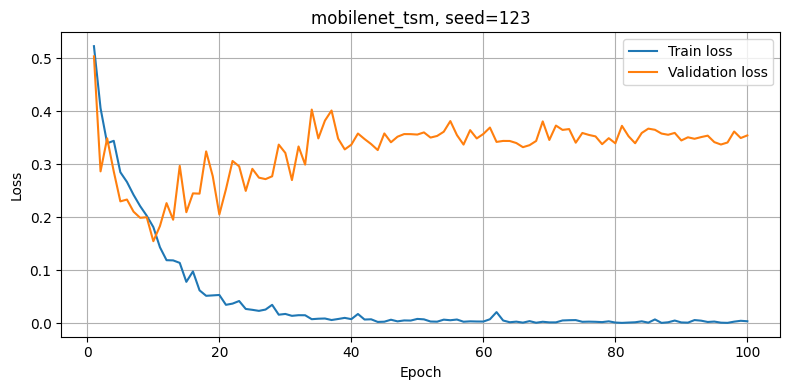

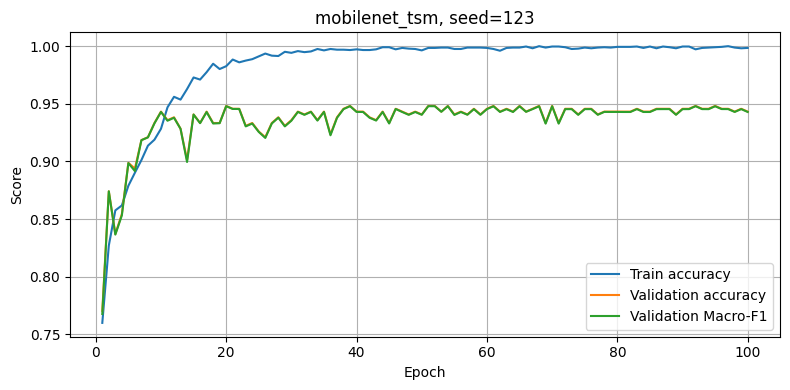

,dataset,n,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,average_precision
0,HF,100,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,MF,20,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,VCF,26,0.8846,0.8869,0.8846,0.8844,0.9645,0.9682
3,AVDV,35,0.9714,0.9792,0.9583,0.9676,1.0000,1.0000
4,SCFD,30,0.7667,0.8000,0.7667,0.7600,0.8844,0.8859
5,RLVS,200,0.9500,0.9516,0.9500,0.9500,0.9825,0.9874
6,RWF,1998,0.6827,0.6889,0.6826,0.6800,0.7632,0.7762
7,ALL_TESTS_POOLED,411,0.9489,0.9489,0.9488,0.9489,0.9872,0.9900


In [11]:
result_df = run_experiment(
    SEEDS[0]
)

display(
    result_df[
        [
            "dataset",
            "n",
            "accuracy",
            "precision_macro",
            "recall_macro",
            "f1_macro",
            "roc_auc",
            "average_precision",
        ]
    ].round(4)
)

## 9. Complexity dan latency

In [12]:
def synchronize_device():
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

@torch.inference_mode()
def benchmark_latency(
    model: nn.Module,
    warmup: int = LATENCY_WARMUP,
    runs: int = LATENCY_RUNS,
):
    model.eval()

    dummy = torch.randn(
        1,
        NUM_SEGMENTS,
        3,
        RAW_HEIGHT,
        RAW_WIDTH,
        device=DEVICE,
    )

    for _ in range(warmup):
        _ = model(dummy)

    synchronize_device()

    times_ms = []

    for _ in range(runs):
        synchronize_device()

        start = time.perf_counter()

        _ = model(dummy)

        synchronize_device()

        times_ms.append(
            (
                time.perf_counter()
                - start
            )
            * 1000.0
        )

    times_ms = np.asarray(
        times_ms,
        dtype=np.float64,
    )

    return {
        "latency_mean_ms": float(times_ms.mean()),
        "latency_std_ms": float(times_ms.std(ddof=0)),
        "latency_p50_ms": float(np.percentile(times_ms, 50)),
        "latency_p90_ms": float(np.percentile(times_ms, 90)),
        "latency_p95_ms": float(np.percentile(times_ms, 95)),
        "latency_p99_ms": float(np.percentile(times_ms, 99)),
    }

def benchmark_completed_model(
    seed: int,
):
    run_dir = (
        OUTPUT_DIR
        / MODEL_VARIANT
        / f"seed_{seed}"
    )

    checkpoint_path = (
        run_dir / "best.pt"
    )

    if not checkpoint_path.exists():
        raise FileNotFoundError(
            checkpoint_path
        )

    model = VideoMobileNetComparator(
        use_tsm=USE_TSM,
        pretrained=False,
    ).to(DEVICE)

    checkpoint = safe_torch_load(
        checkpoint_path,
        map_location=DEVICE,
    )

    model.load_state_dict(
        checkpoint[
            "model_state_dict"
        ]
    )

    model.eval()

    total_params, trainable_params = count_parameters(
        model
    )

    result = {
        "variant": MODEL_VARIANT,
        "checkpoint_seed": seed,
        "device": str(DEVICE),
        "device_name": (
            torch.cuda.get_device_name(0)
            if DEVICE.type == "cuda"
            else platform.processor()
        ),
        "num_segments": NUM_SEGMENTS,
        "input_shape": [
            1,
            NUM_SEGMENTS,
            3,
            RAW_HEIGHT,
            RAW_WIDTH,
        ],
        "internal_resolution": [
            BACKBONE_INPUT_SIZE,
            BACKBONE_INPUT_SIZE,
        ],
        "tsm_blocks": model.tsm_blocks,
        "total_parameters": total_params,
        "trainable_parameters": trainable_params,
    }

    result.update(
        benchmark_latency(model)
    )

    try:
        from ptflops import (
            get_model_complexity_info
        )

        macs, params = (
            get_model_complexity_info(
                model,
                (
                    NUM_SEGMENTS,
                    3,
                    RAW_HEIGHT,
                    RAW_WIDTH,
                ),
                as_strings=False,
                print_per_layer_stat=False,
                verbose=False,
            )
        )

        result[
            "ptflops_macs"
        ] = float(macs)

        result[
            "ptflops_gmacs"
        ] = float(
            macs / 1e9
        )

        result[
            "ptflops_parameters"
        ] = float(params)

    except Exception as error:
        result[
            "ptflops_error"
        ] = repr(error)

    return result

benchmark_result = benchmark_completed_model(
    SEEDS[0]
)

display(
    pd.DataFrame(
        [benchmark_result]
    )
)

pd.DataFrame(
    [benchmark_result]
).to_csv(
    OUTPUT_DIR
    / f"benchmark_{MODEL_VARIANT}_seed{SEEDS[0]}.csv",
    index=False,
)

,variant,checkpoint_seed,device,device_name,num_segments,input_shape,internal_resolution,tsm_blocks,total_parameters,trainable_parameters,latency_mean_ms,latency_std_ms,latency_p50_ms,latency_p90_ms,latency_p95_ms,latency_p99_ms,ptflops_macs,ptflops_gmacs,ptflops_parameters
0,mobilenet_tsm,123,cuda,NVIDIA A100-SXM4-40GB,8,"[1, 8, 3, 64, 64]","[224, 224]",10,2226434,2226434,6.620156,0.107249,6.600213,6.68108,6.718981,6.973704,2.553377e+09,2.553377,2226434.0


## 10. Arsip hasil

In [13]:
archive_base = str(
    OUTPUT_DIR.parent
    / f"{OUTPUT_DIR.name}_results"
)

archive_path = shutil.make_archive(
    archive_base,
    "zip",
    root_dir=OUTPUT_DIR,
)

print("ZIP:", archive_path)
print("Results remain in:", OUTPUT_DIR)

ZIP: /content/drive/MyDrive/IVS/ViolenceDetection/Models/Comparators/mobilenet_tsm_Seed123_v1_results.zip
Results remain in: /content/drive/MyDrive/IVS/ViolenceDetection/Models/Comparators/mobilenet_tsm_Seed123_v1
